In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib
matplotlib.rcParams['pdf.use14corefonts'] = True


In [2]:
# Set the working directory
os.chdir('/scratch/mjehangir/manuscript_figures/figures')

In [3]:
# Verify the current directory
print("Current Directory:", os.getcwd())

Current Directory: /scratch/mjehangir/manuscript_figures/figures


In [4]:
# Load the data
data = pd.read_csv("sniffles_merged_all_samples_SVs_v6.txt", sep="\t")

# Ensure 'start' and 'end' columns are numeric (convert if needed)
data['start'] = pd.to_numeric(data['start'], errors='coerce')
data['end'] = pd.to_numeric(data['end'], errors='coerce')

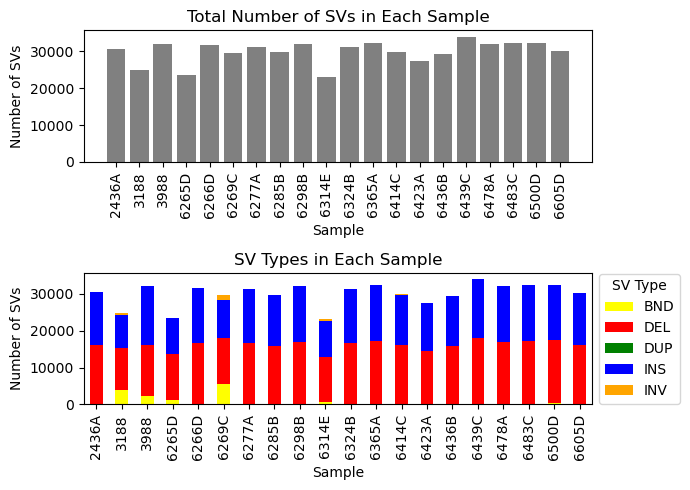

In [5]:
# Create a new column for the SV length
data['length'] = data['end'] - data['start'] + 1

# Sort the data by sample in ascending order
sample_order = sorted(data['filename'].unique())

# Create a 2x1 grid of subplots (2 rows, 1 column)
fig, axs = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Total Number of SVs in Each Sample ---
# Count the number of SVs per sample
sv_counts = data['filename'].value_counts().reindex(sample_order)

# Plot total number of SVs per sample with the sample order
axs[0].bar(sv_counts.index, sv_counts.values, color='gray')
axs[0].set_title("Total Number of SVs in Each Sample")
axs[0].set_xlabel("Sample")
axs[0].set_ylabel("Number of SVs")
axs[0].tick_params(axis='x', rotation=90)

# --- Plot 2: Different Types of SVs in Each Sample ---
# Group by sample and SV type to get counts of each SV type
sv_types = data.groupby(['filename', 'type']).size().unstack(fill_value=0)

# Reorder the rows (samples) in the sv_types DataFrame based on the sample_order
sv_types = sv_types.loc[sample_order]  # Reorder rows by sample_order

# Define colors for each SV type
colors = {'INS': 'blue', 'DEL': 'red', 'DUP': 'green', 'INV': 'orange', 'BND': 'yellow'}

# Plot different types of SVs in each sample with custom colors
sv_types.plot(
    kind='bar', 
    stacked=True, 
    ax=axs[1], 
    figsize=(7, 5), 
    color=[colors.get(x, 'gray') for x in sv_types.columns]
)
axs[1].set_title("SV Types in Each Sample")
axs[1].set_xlabel("Sample")
axs[1].set_ylabel("Number of SVs")
axs[1].tick_params(axis='x', rotation=90)

# Place the legend on the right side of the second plot
axs[1].legend(title='SV Type', loc='center left', bbox_to_anchor=(1, 0.5))

# Adjust layout to prevent overlapping
plt.tight_layout()

# Save the figure to a file (e.g., PNG or PDF)
plt.savefig("SVs_count_and_types2.pdf", dpi=300, format="pdf")  # Save as PNG with high resolution
# Show the plot
plt.show()

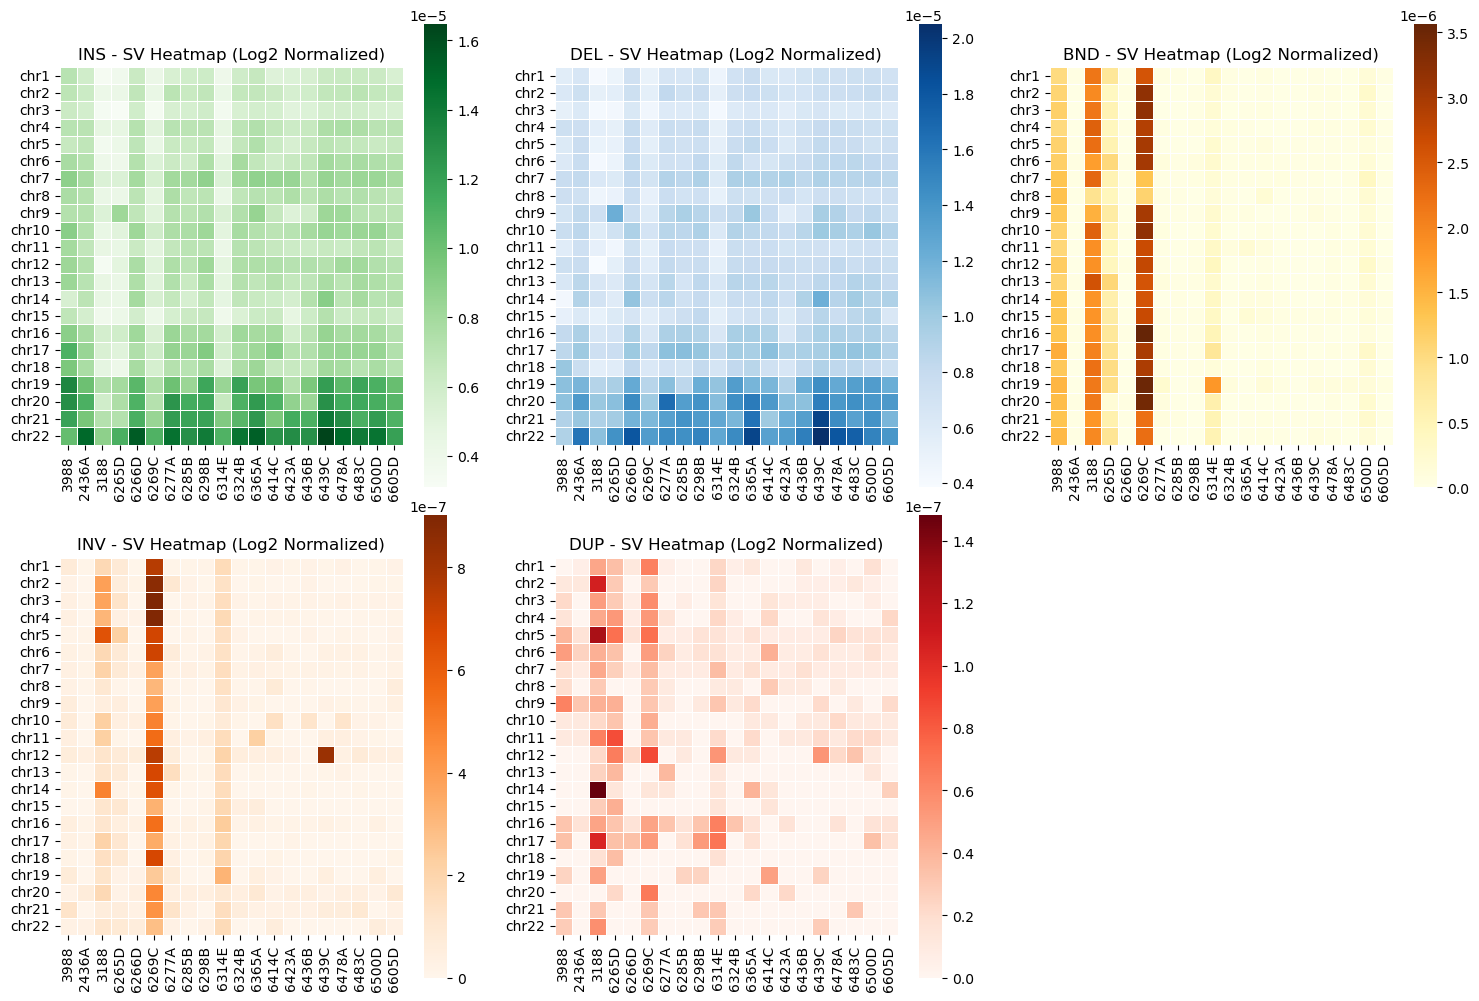

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load the SV data
file_path = 'sniffles_merged_all_samples_SVs_v6.txt'  # Adjust this path
df = pd.read_csv(file_path, sep="\t")

# Filter out unwanted chromosomes (e.g., 'chrM', 'chr', etc.)
df = df[~df['chr'].isin(['chrM', 'chr'])]

# Define T2T chromosome sizes (in base pairs)
chrom_sizes = {
    'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559, 'chr4': 190214555,
    'chr5': 181538259, 'chr6': 170805979, 'chr7': 159345973, 'chr8': 145138636,
    'chr9': 138394717, 'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
    'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189, 'chr16': 90338345,
    'chr17': 83257441, 'chr18': 80373285, 'chr19': 58617616, 'chr20': 64444167,
    'chr21': 46709983, 'chr22': 50818468
}

# Filter out chromosomes not in T2T assembly
df = df[df['chr'].isin(chrom_sizes.keys())]

# Get the unique SV types
sv_types = df['type'].unique()

# Define explicit colormaps for each SV type
sv_colors = {
    'INS': cm.Greens,   # Insertions - Blue
    'DEL': cm.Blues,    # Deletions - Red
    'DUP': cm.Reds,  # Duplications - Green
    'INV': cm.Oranges, # Inversions - Orange
    'BND': cm.YlOrBr   # Breakends - Yellow-Orange-Brown colormap
}

# Increase the figure size for larger heatmaps
fig, axes = plt.subplots(2, int(np.ceil(len(sv_types) / 2)), figsize=(15, 10))
axes = axes.flatten()

# Loop through the SV types
for i, sv_type in enumerate(sv_types):
    ax = axes[i]

    # Filter the dataframe for the current SV type
    df_sv_type = df[df['type'] == sv_type]

    # Create an empty DataFrame to store the count of each SV type per chromosome for all samples
    sv_count_by_chr = pd.DataFrame(columns=df['filename'].unique(), index=chrom_sizes.keys())

    # Fill the dataframe with the counts of the current SV type per chromosome for each sample
    for chrom in chrom_sizes.keys():
        for sample in df['filename'].unique():
            count = len(df_sv_type[(df_sv_type['chr'] == chrom) & (df_sv_type['filename'] == sample)])
            sv_count_by_chr.at[chrom, sample] = count

    # Normalize by chromosome size
    for chrom in sv_count_by_chr.index:
        size = chrom_sizes.get(chrom, 0)  # Get the size for the chromosome
        if size > 0:
            sv_count_by_chr.loc[chrom] = sv_count_by_chr.loc[chrom] / size

    # Convert to float and apply log2 transformation
    sv_count_by_chr = sv_count_by_chr.astype(float)  # Convert to float
    sv_count_by_chr_log = np.log2(sv_count_by_chr + 1)  # Adding 1 to avoid log(0)

    # Create the heatmap for the current SV type
    sns.heatmap(
        sv_count_by_chr_log, annot=False, cmap=sv_colors.get(sv_type, cm.Blues), linewidths=0.7, ax=ax, square=True,
        xticklabels=True, yticklabels=True, cbar=True, cbar_kws={'shrink': 1.2}
    )

    # Set the title for each subplot
    ax.set_title(f'{sv_type} - SV Heatmap (Log2 Normalized)', fontsize=12)

# Remove extra axes if not used
for j in range(len(sv_types), len(axes)):
    fig.delaxes(axes[j])

# Adjust subplot layout to avoid overlap and ensure visibility
plt.tight_layout()

plt.savefig("heatmaps_SVs_type.pdf", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()


/tmp/ipykernel_2949949/3636826447.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2949949/3636826447.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(sample_order, rotation=90, fontsize=12)
/tmp/ipykernel_2949949/3636826447.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2949949/3636826447.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(sample_order, rotation=90, fontsize=12)
/tmp/ipykernel_2949949/3636826447.py:57: FutureW

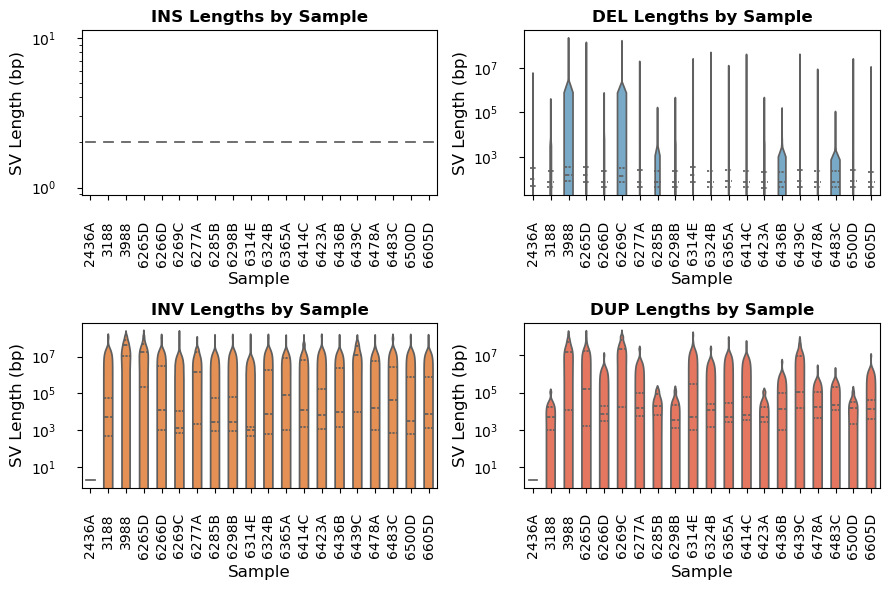

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import numpy as np

# Load the data
data = pd.read_csv("sniffles_merged_all_samples_SVs_v6.txt", sep="\t")

# Ensure 'start' and 'end' columns are numeric
data['start'] = pd.to_numeric(data['start'], errors='coerce')
data['end'] = pd.to_numeric(data['end'], errors='coerce')

# Create a new column for the SV length
data['length'] = data['end'] - data['start'] + 1

# Filter out non-positive values from the length column
data = data[data['length'] > 0]

# Exclude BND (Breakpoint) SV types
data = data[data['type'] != 'BND']

# Define explicit colormaps for each SV type
sv_colors = {
    'INS': cm.Greens,   # Insertions - Blue
    'DEL': cm.Blues,    # Deletions - Red
    'DUP': cm.Reds,  # Duplications - Green
    'INV': cm.Oranges, # Inversions - Orange
    'BND': cm.YlOrBr   # Breakends - Yellow-Orange-Brown colormap
}

# Sort the data by sample in ascending order
sample_order = sorted(data['filename'].unique())

# --- Create a figure with subplots for each SV type ---
sv_types = data['type'].unique()

# Calculate the number of rows and columns for the subplots (2 columns per row)
n_cols = 2
n_rows = int(np.ceil(len(sv_types) / n_cols))  # Round up to the nearest integer

# Adjust figure height and width for better space utilization
fig, axs = plt.subplots(n_rows, n_cols, figsize=(9, 3 * n_rows))

# Flatten the axes to make it easier to iterate over
axs = axs.flatten()

# Loop over each SV type to create a violin plot
for i, sv_type in enumerate(sv_types):
    # Filter data for the current SV type
    sv_data = data[data['type'] == sv_type]
    
    # Get the colormap for the current SV type
    cmap = sv_colors.get(sv_type, cm.Greys)  # Default to Greys if the type is not found
    
    # Violin plot for SV length by sample for each SV type
    sns.violinplot(
        x='filename', y='length', data=sv_data, ax=axs[i], inner="quart",
        width=0.5, palette=[cmap(0.5)] * len(sample_order)  # Apply the selected colormap
    )

    # Set plot labels and title with larger font size for publication quality
    axs[i].set_xticklabels(sample_order, rotation=90, fontsize=12)
    axs[i].set_title(f"{sv_type} Lengths by Sample", fontweight='bold', fontsize=12)
    axs[i].set_xlabel("Sample", fontsize=12)
    axs[i].set_ylabel("SV Length (bp)", fontsize=12)

    # Use log scale for the y-axis to better visualize the range of SV lengths
    axs[i].set_yscale('log')

    # Remove gridlines for cleaner presentation
    axs[i].grid(False)

    # Increase the padding between the axis labels and ticks
    axs[i].tick_params(axis='x', which='major', pad=15, labelsize=10)
    axs[i].tick_params(axis='y', which='major', pad=15, labelsize=10)

# If there are more subplots than available axes, turn off extra subplots
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Save the figure as a high-resolution PDF for publication quality
plt.savefig("sv_type_colormap_violin_plots.pdf", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()


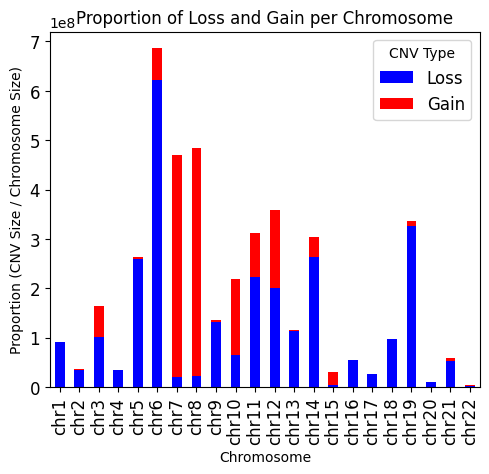

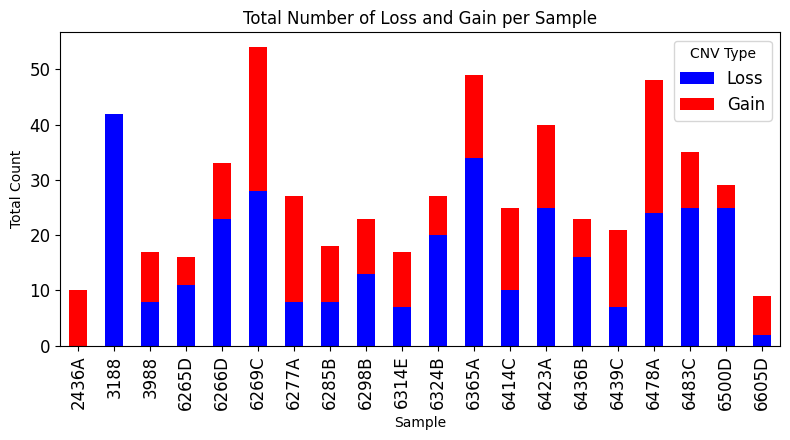

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Chromosome size information for CHM13 genome
chromosome_sizes = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468
}

# Load data
file_path = '/scratch/mjehangir/Maria_arm_aneuploidy_analysis/renamed_zscore-filtered_segmentation_output_v2.call.seg'
data = pd.read_csv(file_path, sep="\t")

# Determine CNV Type: 'Gain', 'Loss', or 'Neutral'
data["CNV_Type"] = data["MEAN_LOG2_COPY_RATIO"].apply(lambda x: "Gain" if x > 0 else ("Loss" if x < 0 else "Neutral"))

# Calculate CNV Size
data["CNV_Size"] = data["END"] - data["START"]

# Aggregate by chromosome and CNV type
cnv_aggregated = data[data["CNV_Type"] != "Neutral"].groupby(["CONTIG", "CNV_Type"])["CNV_Size"].sum().unstack(fill_value=0)

# Add chromosome sizes
cnv_aggregated["Chromosome Size"] = pd.Series(chromosome_sizes)

# Normalize for proportion
cnv_aggregated["Loss_Proportion"] = cnv_aggregated["Loss"] / cnv_aggregated["Chromosome Size"]
cnv_aggregated["Gain_Proportion"] = cnv_aggregated["Gain"] / cnv_aggregated["Chromosome Size"]


# Sort the chromosomes numerically
chromosome_order = [f"chr{i}" for i in range(1, 23)]  # List chromosomes in the desired order
cnv_aggregated = cnv_aggregated.loc[chromosome_order]

# Stacked Bar Chart for Proportions
cnv_aggregated[["Loss", "Gain"]].plot(
    kind="bar", stacked=True, color=["blue", "red"], figsize=(5, 5),
    ylabel="Proportion (CNV Size / Chromosome Size)", xlabel="Chromosome",
    title="Proportion of Loss and Gain per Chromosome"
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="CNV Type", fontsize=12)
plt.tight_layout()

#plt.savefig("barchart_CNVs_loss_gain_per_chr.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Count the number of gains and losses per sample
cnv_counts_samples = data[data["CNV_Type"] != "Neutral"].groupby(["SampleID", "CNV_Type"]).size().unstack(fill_value=0)

# Bar Plot for Total Counts of Gain and Loss per Sample
cnv_counts_samples[["Loss", "Gain"]].plot(
    kind="bar", stacked=True, color=["blue", "red"], figsize=(8, 4.5),
    ylabel="Total Count", xlabel="Sample",
    title="Total Number of Loss and Gain per Sample"
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="CNV Type", fontsize=12)
plt.tight_layout()

plt.savefig("barchart_CNV_counts_loss_gain_per_sample.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [46]:
print(data.columns)


Index(['SampleID', 'CONTIG', 'START', 'END', 'num.mark',
       'MEAN_LOG2_COPY_RATIO', 'CALL', 'CNV_Type', 'CNV_Size'],
      dtype='object')


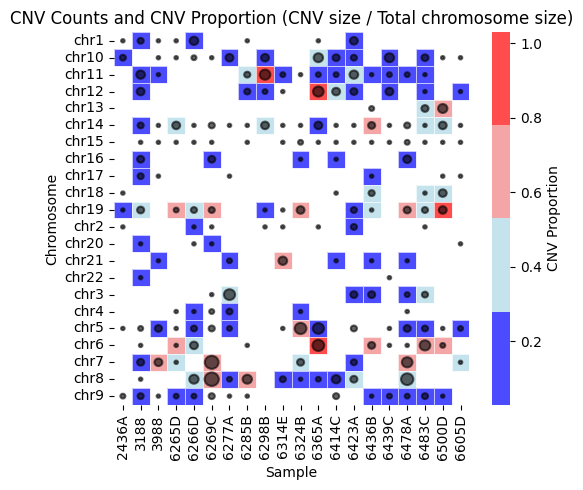

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors

# Chromosome size information for CHM13 genome
chromosome_sizes = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468, 
}

# Load data
file_path = '/scratch/mjehangir/Maria_arm_aneuploidy_analysis/renamed_zscore-filtered_segmentation_output_v2.call.seg'
data = pd.read_csv(file_path, sep="\t")


# Determine CNV Type: 'Gain', 'Loss', or 'Neutral'
data["CNV_Type"] = data["MEAN_LOG2_COPY_RATIO"].apply(lambda x: "Gain" if x > 0 else ("Loss" if x < 0 else "Neutral"))

# Calculate CNV Size
data["CNV_Size"] = data["END"] - data["START"]

# Calculate CNV proportion per sample and chromosome
data["CNV_Proportion"] = data["CNV_Size"] / data["CONTIG"].map(chromosome_sizes)

# Step 1: Calculate CNV count per sample and chromosome
cnv_count = data.groupby(["CONTIG", "SampleID"])["CNV_Type"].count().unstack(fill_value=0)

# Step 2: Aggregate CNV proportion by sample and chromosome
cnv_proportion = data.groupby(["CONTIG", "SampleID"])["CNV_Proportion"].sum().unstack(fill_value=0)

# Set a threshold for CNV proportion to be considered white (e.g., 0.05)
threshold = 0.03

# Step 3: Create a custom colormap to map values below the threshold to white
colors = ["blue", "lightblue", "lightcoral", "red"]# Define a simple range of colors
cmap = mcolors.ListedColormap(colors)

# Step 4: Mask values below the threshold as NaN to show them as white
masked_cnv_proportion = cnv_proportion.copy()
masked_cnv_proportion[masked_cnv_proportion < threshold] = np.nan



# Step 5: Plot the heatmap
plt.figure(figsize=(5.5, 5))

# Plot CNV Proportion heatmap with color intensity (blue for loss, red for gain)
sns.heatmap(masked_cnv_proportion, cmap=cmap, annot=False, fmt=".2f", linewidths=.5, cbar_kws={'label': 'CNV Proportion'}, alpha=0.7)

# Overlay circles to represent CNV counts (circle size reflects the count)
for i in range(masked_cnv_proportion.shape[0]):
    for j in range(masked_cnv_proportion.shape[1]):
        count = cnv_count.iloc[i, j]
        if count > 0:  # Only plot a circle if there is a CNV count
            # Scale circle size to fit within the matrix cell
            circle_size = np.sqrt(count) * 0.1  # Adjust the factor (0.1) to scale appropriately
            # Plot circle at position (j, i) in axes coordinates (x, y)
            plt.gca().add_patch(plt.Circle((j + 0.5, i + 0.5), radius=circle_size, color="black", linewidth=1.5, alpha=0.6))

# Customize the plot
plt.title('CNV Counts and CNV Proportion (CNV size / Total chromosome size)')
plt.xlabel('Sample')
plt.ylabel('Chromosome')
plt.tight_layout()
plt.savefig("heatmap_CNV_count_and_proportion.pdf", dpi=300, bbox_inches="tight")
# Show the plot
plt.show()




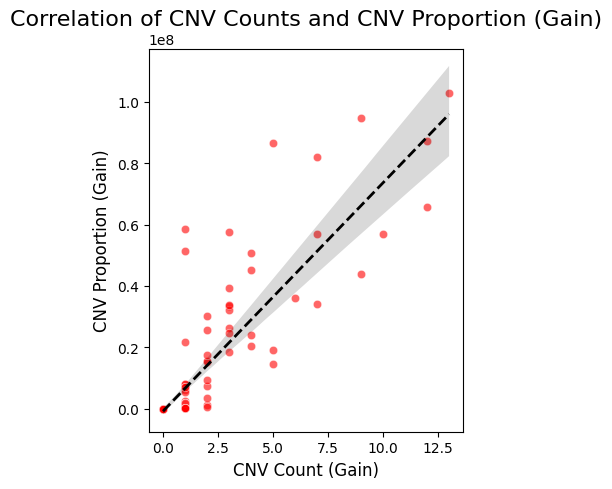

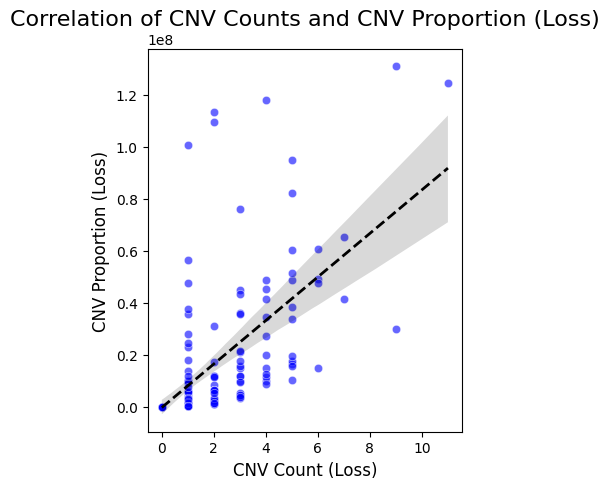

Pearson correlation coefficient (Gain): 0.87
Pearson correlation coefficient (Loss): 0.66


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Chromosome size information for CHM13 genome
chromosome_sizes = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468
}

# Load data
file_path = '/scratch/mjehangir/Maria_arm_aneuploidy_analysis/renamed_zscore-filtered_segmentation_output_v2.call.seg'
data = pd.read_csv(file_path, sep="\t")

# Determine CNV Type: 'Gain', 'Loss', or 'Neutral'
data["CNV_Type"] = data["MEAN_LOG2_COPY_RATIO"].apply(lambda x: "Gain" if x > 0 else ("Loss" if x < 0 else "Neutral"))

# Calculate CNV Size
data["CNV_Size"] = data["END"] - data["START"]

# Calculate CNV proportion per sample and chromosome
data["CNV_Proportion"] = data["CNV_Size"] / data["CONTIG"].map(chromosome_sizes)

# Step 1: Calculate CNV count per sample and chromosome
cnv_count = data.groupby(["CONTIG", "SampleID", "CNV_Type"])["CNV_Type"].count().unstack(fill_value=0)

# Step 2: Aggregate CNV size by sample and chromosome
cnv_size = data.groupby(["CONTIG", "SampleID", "CNV_Type"])["CNV_Size"].sum().unstack(fill_value=0)

# Filter data by CNV type (Gain or Loss)
cnv_count_gain = cnv_count["Gain"]
cnv_size_gain = cnv_size["Gain"]

cnv_count_loss = cnv_count["Loss"]
cnv_size_loss = cnv_size["Loss"]

# Step 3: Create the scatter plot for Gain CNVs
plt.figure(figsize=(4, 5))

sns.scatterplot(x=cnv_count_gain.values.flatten(), y=cnv_size_gain.values.flatten(), color='red', alpha=0.6)
sns.regplot(x=cnv_count_gain.values.flatten(), y=cnv_size_gain.values.flatten(), scatter=False, color='black', line_kws={'lw': 2, 'ls': '--'})

plt.title('Correlation of CNV Counts and CNV Proportion (Gain)', fontsize=16)
plt.xlabel('CNV Count (Gain)', fontsize=12)
plt.ylabel('CNV Proportion (Gain)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 4: Create the scatter plot for Loss CNVs
plt.figure(figsize=(4, 5))

sns.scatterplot(x=cnv_count_loss.values.flatten(), y=cnv_size_loss.values.flatten(), color='blue', alpha=0.6)
sns.regplot(x=cnv_count_loss.values.flatten(), y=cnv_size_loss.values.flatten(), scatter=False, color='black', line_kws={'lw': 2, 'ls': '--'})

plt.title('Correlation of CNV Counts and CNV Proportion (Loss)', fontsize=16)
plt.xlabel('CNV Count (Loss)', fontsize=12)
plt.ylabel('CNV Proportion (Loss)', fontsize=12)
plt.tight_layout()

plt.savefig("scatterplots_correlation_CNV_count_proportion.pdf", dpi=300, bbox_inches="tight")

plt.show()

# Optional: Calculate Pearson correlation coefficients for Gain and Loss
correlation_gain = np.corrcoef(cnv_count_gain.values.flatten(), cnv_size_gain.values.flatten())[0, 1]
correlation_loss = np.corrcoef(cnv_count_loss.values.flatten(), cnv_size_loss.values.flatten())[0, 1]

print(f'Pearson correlation coefficient (Gain): {correlation_gain:.2f}')
print(f'Pearson correlation coefficient (Loss): {correlation_loss:.2f}')


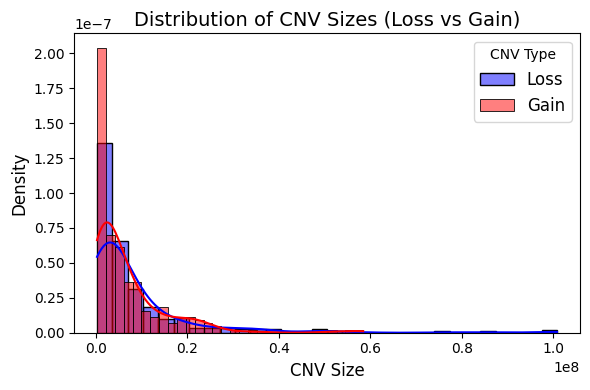

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming `data` already contains 'CNV_Type' and 'CNV_Size' columns

# Create separate dataframes for 'Loss' and 'Gain'
loss_data = data[data["CNV_Type"] == "Loss"]
gain_data = data[data["CNV_Type"] == "Gain"]

# Create the plot
plt.figure(figsize=(6, 4))

# Plot 'Loss' CNVs in blue
sns.histplot(loss_data["CNV_Size"], kde=True, color="blue", label="Loss", bins=30, stat="density")

# Plot 'Gain' CNVs in red
sns.histplot(gain_data["CNV_Size"], kde=True, color="red", label="Gain", bins=30, stat="density")

# Customize the plot
plt.title('Distribution of CNV Sizes (Loss vs Gain)', fontsize=14)
plt.xlabel('CNV Size', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title="CNV Type", fontsize=12)
plt.tight_layout()
plt.savefig("distributon_plot_CNVs_count_size.pdf", dpi=300, bbox_inches="tight")

plt.show()


In [65]:
print(data.head())

  SampleID CONTIG      START        END  num.mark  MEAN_LOG2_COPY_RATIO CALL  \
0    2436A   chr1  142707663  142907814         1                2.2816    +   
1    2436A  chr10  113132775  120741705         1                0.5261    -   
2    2436A  chr10  123144525  124546170         1                0.6311    -   
3    2436A  chr10  124746405  134357666         1                0.4670    -   
4    2436A  chr18   39469935   39670290         1                0.4407    -   

  CNV_Type  CNV_Size  CNV_Proportion  
0     Gain    200151        0.000804  
1     Gain   7608930        0.056869  
2     Gain   1401645        0.010476  
3     Gain   9611261        0.071834  
4     Gain    200355        0.002493  


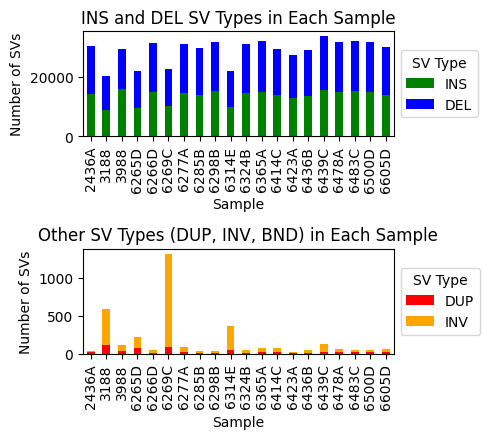

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by sample and SV type to get counts of each SV type
sv_types = data.groupby(['filename', 'type']).size().unstack(fill_value=0)

# Reorder the rows (samples) in the sv_types DataFrame based on the sample_order
sample_order = sorted(data['filename'].unique())
sv_types = sv_types.loc[sample_order]

# Separate INS and DEL from the rest of the SV types
ins_del_types = sv_types[['INS', 'DEL']]  # Keep only INS and DEL
other_sv_types = sv_types.drop(columns=['INS', 'DEL'], errors='ignore')  # Drop INS and DEL from other types

# Define colors for each SV type
colors = {'INS': 'Green', 'DEL': 'Blue', 'DUP': 'Red', 'INV': 'orange', 'BND': 'yellow'}

# Create subplots with 2 rows and 1 column
fig, axs = plt.subplots(2, 1, figsize=(5, 4.5))  # Adjust figure size

# --- Plot 1: INS and DEL SV Types ---
ins_del_types.plot(
    kind='bar',
    stacked=True,
    ax=axs[0],
    color=[colors.get(x, 'gray') for x in ins_del_types.columns]
)
axs[0].set_title("INS and DEL SV Types in Each Sample")
axs[0].set_xlabel("Sample")
axs[0].set_ylabel("Number of SVs")
axs[0].tick_params(axis='x', rotation=90)

# --- Plot 2: Other SV Types (DUP, INV, BND) ---
other_sv_types.plot(
    kind='bar',
    stacked=True,
    ax=axs[1],
    color=[colors.get(x, 'gray') for x in other_sv_types.columns]
)
axs[1].set_title("Other SV Types (DUP, INV, BND) in Each Sample")
axs[1].set_xlabel("Sample")
axs[1].set_ylabel("Number of SVs")
axs[1].tick_params(axis='x', rotation=90)

# Add legends to the plots
for ax in axs:
    ax.legend(title='SV Type', loc='center left', bbox_to_anchor=(1, 0.5))

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure
plt.savefig("INS_DEL_and_Other_SV_Types.pdf", dpi=300, format="pdf")
plt.show()


/tmp/ipykernel_3950695/3764527027.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cnv_count = data.groupby(["CONTIG", "SampleID"])["CNV_Type"].count().unstack(fill_value=0)
/tmp/ipykernel_3950695/3764527027.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cnv_proportion = data.groupby(["CONTIG", "SampleID"])["CNV_Proportion"].sum().unstack(fill_value=0)
/tmp/ipykernel_3950695/3764527027.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default 

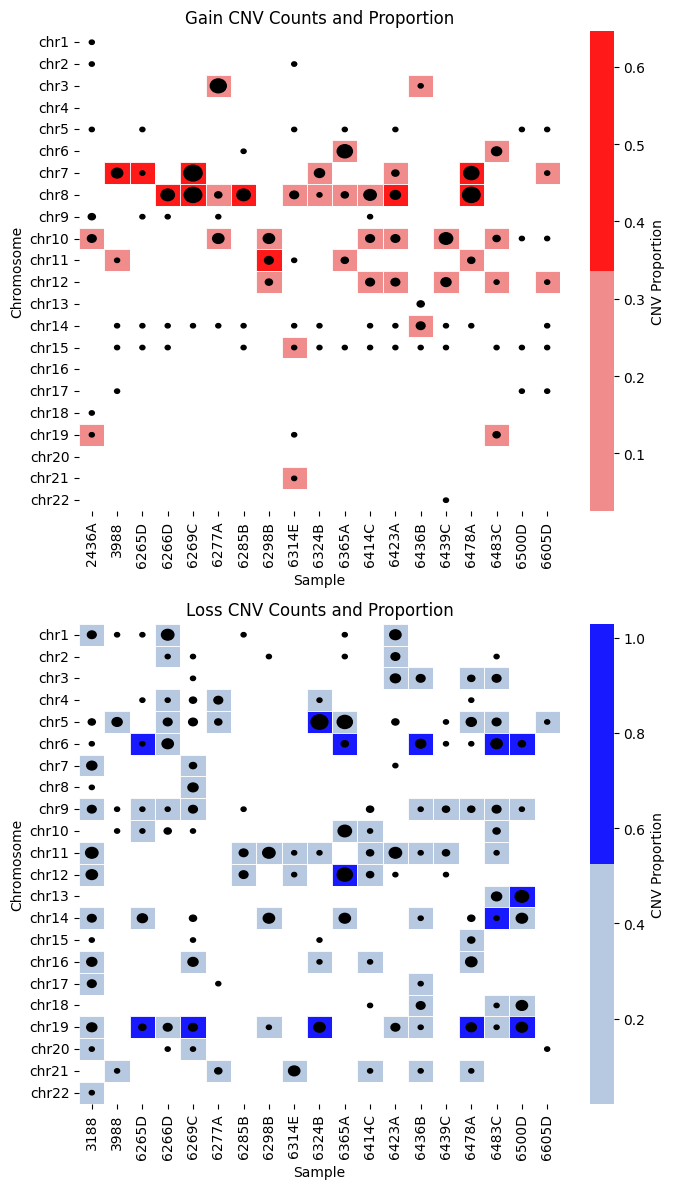

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
matplotlib.rcParams['pdf.use14corefonts'] = True
# Chromosome size information for CHM13 genome
chromosome_sizes = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468,
}

# Load data
file_path = '/scratch/mjehangir/Maria_arm_aneuploidy_analysis/renamed_zscore-filtered_segmentation_output_v2.call.seg'
data = pd.read_csv(file_path, sep="\t")

# Sort chromosomes numerically based on the order in chromosome_sizes
chromosome_order = list(chromosome_sizes.keys())
data["CONTIG"] = pd.Categorical(data["CONTIG"], categories=chromosome_order, ordered=True)
data.sort_values("CONTIG", inplace=True)

# Determine CNV Type: 'Gain', 'Loss', or 'Neutral'
data["CNV_Type"] = data["MEAN_LOG2_COPY_RATIO"].apply(lambda x: "Gain" if x > 0 else ("Loss" if x < 0.5 else "Neutral"))

# Calculate CNV Size
data["CNV_Size"] = data["END"] - data["START"]

# Calculate CNV proportion per sample and chromosome
data["CNV_Proportion"] = data["CNV_Size"] / data["CONTIG"].astype(str).map(chromosome_sizes)

# Step 1: Calculate CNV count per sample and chromosome
cnv_count = data.groupby(["CONTIG", "SampleID"])["CNV_Type"].count().unstack(fill_value=0)

# Step 2: Aggregate CNV proportion by sample and chromosome
cnv_proportion = data.groupby(["CONTIG", "SampleID"])["CNV_Proportion"].sum().unstack(fill_value=0)

# Set a threshold for CNV proportion to be considered white (e.g., 0.03)
threshold = 0.02

# Step 3: Mask values below the threshold as NaN to show them as white
masked_cnv_proportion = cnv_proportion.copy()
masked_cnv_proportion[masked_cnv_proportion < threshold] = np.nan

# Separate data for "Gain" and "Loss"
data_gain = data[data["CNV_Type"] == "Gain"]
data_loss = data[data["CNV_Type"] == "Loss"]

# Calculate CNV counts and proportions for Gain and Loss separately
cnv_count_gain = data_gain.groupby(["CONTIG", "SampleID"])["CNV_Type"].count().unstack(fill_value=0)
cnv_count_loss = data_loss.groupby(["CONTIG", "SampleID"])["CNV_Type"].count().unstack(fill_value=0)

cnv_proportion_gain = data_gain.groupby(["CONTIG", "SampleID"])["CNV_Proportion"].sum().unstack(fill_value=0)
cnv_proportion_loss = data_loss.groupby(["CONTIG", "SampleID"])["CNV_Proportion"].sum().unstack(fill_value=0)

# Mask CNV proportion for Gain and Loss
masked_cnv_proportion_gain = cnv_proportion_gain.copy()
masked_cnv_proportion_loss = cnv_proportion_loss.copy()

masked_cnv_proportion_gain[masked_cnv_proportion_gain < threshold] = np.nan
masked_cnv_proportion_loss[masked_cnv_proportion_loss < threshold] = np.nan

# Create a function to plot and save the heatmap as PDF
def plot_cnv_heatmap(cnv_proportion_data, cnv_count_data, ax, plot_title, cmap, alpha=0.7):
    sns.heatmap(cnv_proportion_data, cmap=cmap, annot=False, fmt=".2f", linewidths=.5,
                cbar_kws={'label': 'CNV Proportion'}, alpha=alpha, ax=ax)

    # Overlay circles to represent CNV counts (circle size reflects the count)
    for i in range(cnv_proportion_data.shape[0]):
        for j in range(cnv_proportion_data.shape[1]):
            count = cnv_count_data.iloc[i, j]
            if count > 0:  # Only plot a circle if there is a CNV count
                # Scale circle size to fit within the matrix cell
                circle_size = np.sqrt(count) * 0.1  # Adjust the factor (0.1) to scale appropriately
                # Plot circle at position (j, i) in axes coordinates (x, y)
                ax.add_patch(plt.Circle((j + 0.5, i + 0.5), radius=circle_size, color="black", linewidth=1, alpha=1))

    ax.set_title(plot_title)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Chromosome')

# Custom colormap for Gain (red) and Loss (blue)
gain_cmap = mcolors.ListedColormap(["lightcoral", "red"])
loss_cmap = mcolors.ListedColormap(["lightsteelblue", "blue"])

# Define file path for saving the heatmap as PDF
save_path = '/scratch/mjehangir/heatmap_gain_loss_cnv.pdf'

# Create a figure with subplots (2 rows and 1 column)
fig, axes = plt.subplots(2, 1, figsize=(7, 12))  # Adjust figsize for side-by-side plots

# Plot and save both heatmaps in one figure
plot_cnv_heatmap(masked_cnv_proportion_gain, cnv_count_gain, axes[0], 'Gain CNV Counts and Proportion', gain_cmap, alpha=0.9)
plot_cnv_heatmap(masked_cnv_proportion_loss, cnv_count_loss, axes[1], 'Loss CNV Counts and Proportion', loss_cmap, alpha=0.9)


# Adjust layout to make sure everything fits
plt.tight_layout()

# Save the entire figure as a PDF
plt.savefig(save_path, format='pdf')
plt.show()
# Close the plot to free up memory
plt.close()
